# 02 — Background, autofluorescence, tissue edge, normalisation, QC

Per section, from pyramid level 3 (1.7 µm/px):
- **tissue** mask (smoothed DAPI+18S, Otsu), **distance to tissue edge** per cell
- **cell-free** tissue: > 5 µm from any segmented cell
- **autofluorescence (AF) proxy**: cell-free *and* low transcript density (< 25th percentile of tissue) —
  DAPI-negative, transcript-poor pixels; split by the anatomical region of the nearest annotated cell (WM vs GM)
- **local background** per channel: Gaussian-weighted (σ 25 µm) mean of cell-free pixels, sampled at each cell

Normalisation (intensity features only): `(x − local background) / s_section`, where `s_section` is the 90th
percentile of raw cell means of **physiological-niche** cells in that **section** (one slide region, stained
and imaged together = the technical unit). Pieces within a section also differ, but piece-level intensity
tracks disease (see below), so pieces are not scaled away — tissue piece enters Phase 4 models as a covariate (`Curated_niche_state`), so lesion-rich sections
are not scaled towards their lesion content. (Scaling on background-subtracted values fails: most cells are
dimmer than the ATP1A1 neuropil and αSMA/Vim ≈ 0 in most cells, giving ≤ 0 scales; a raw median is noise-level
for αSMA/Vim — earlier runs, see RESULTS.md.) Ratio-type features (radial, polarity,
texture, morphology) are left as they are.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.measure import block_reduce

from beyondboundaries import background as bgm
from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/02_normalisation_qc.ipynb"
OUT = ROOT / "results" / "02_normalisation_qc"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / "data" / "qc"
CACHE.mkdir(parents=True, exist_ok=True)
cfg = data.load_config()
CH = data.CHANNELS
bundles = find_bundles(cfg)
obs = data.load_obs(cfg)
WM = ["WM", "WM_Meningeal"]
GM = ["GM", "DorsalHorn", "VentralHorn"]

## Per-section maps (cached in `data/qc/`)

In [2]:
for sec, path in bundles.items():
    if (CACHE / f"{sec}_covariates.parquet").exists():
        continue
    b = XeniumBundle(path)
    m = bgm.section_background(b)
    feats = pd.read_parquet(ROOT / cfg["features_dir"] / f"{sec}.parquet",
                            columns=["x_centroid", "y_centroid"])
    cov = bgm.sample_at_cells(m, feats.x_centroid.values, feats.y_centroid.values, CH)
    cov.index = sec + ":" + feats.index
    cov.to_parquet(CACHE / f"{sec}_covariates.parquet")
    o = obs[obs.sample_id == sec]
    xy = np.c_[o.index.map(feats.x_centroid.rename(lambda i: sec + ":" + i)),
               o.index.map(feats.y_centroid.rename(lambda i: sec + ":" + i))]
    for which in ("af", "cellfree"):
        px = bgm.pixels_by_region(m, xy, o.Global_anatomical_region.astype(str).values, CH, which=which)
        px.groupby("region")[CH].agg(["median", "size"]).to_parquet(CACHE / f"{sec}_{which}_by_region.parquet")
    thumbs = {ch: block_reduce(m["img"][ch], 4, np.mean) for ch in CH}
    masks = {k: block_reduce(m[k], 4, np.max) for k in ("tissue", "cellfree", "af")}
    np.savez_compressed(CACHE / f"{sec}_thumbs.npz", **thumbs, **masks,
                        **{f"bg_{ch}": block_reduce(np.nan_to_num(m[f"bg_{ch}"]), 4, np.mean) for ch in CH})
    print(sec, "done", flush=True)

## Tissue / cell-free / AF masks — one section as an example

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/02_normalisation_qc/masks_example.png')

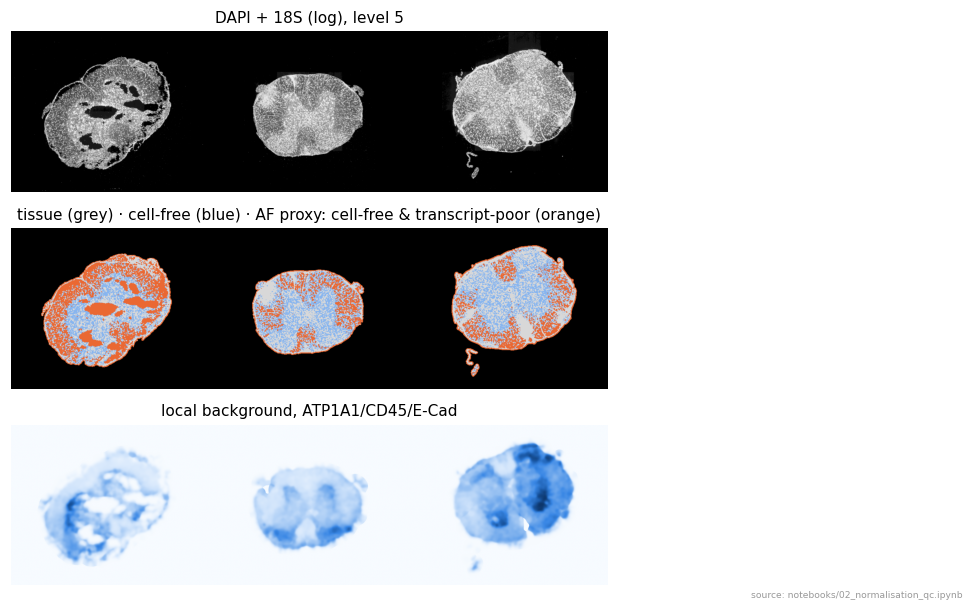

In [3]:
EX = "run5_C2_G1_Mid_0088858"
t = np.load(CACHE / f"{EX}_thumbs.npz")
fig, axs = plt.subplots(3, 1, figsize=(12, 5.5))
axs[0].imshow(np.log1p(t["dapi"] + t["r18s"]), cmap="gray"); axs[0].set_title("DAPI + 18S (log), level 5")
over = np.zeros((*t["tissue"].shape, 3))
over[t["tissue"]] = (0.85, 0.85, 0.85)
over[t["cellfree"]] = (0.53, 0.71, 0.94)
over[t["af"]] = (0.92, 0.41, 0.20)
axs[1].imshow(over); axs[1].set_title("tissue (grey) · cell-free (blue) · AF proxy: cell-free & transcript-poor (orange)")
axs[2].imshow(t["bg_bnd"], cmap=plotting.SEQ); axs[2].set_title("local background, ATP1A1/CD45/E-Cad")
for a in axs:
    a.axis("off")
fig.tight_layout()
plotting.save_fig(fig, "masks_example", OUT, SRC)

## Autofluorescence: white vs grey matter
Median intensity of AF-proxy pixels (cell-free, DAPI-negative, transcript-poor), per section and region.
If myelin autofluorescence matters, WM should be brighter than GM in the channels that are *not* expected
to be extracellular.

In [4]:
rows = []
for sec in bundles:
    for which in ("af", "cellfree"):
        d = pd.read_parquet(CACHE / f"{sec}_{which}_by_region.parquet")
        for reg in d.index:
            for ch in CH:
                rows.append(dict(section=sec, which=which, region=reg, channel=ch,
                                 median=d.loc[reg, (ch, "median")], npx=d.loc[reg, (ch, "size")]))
af = pd.DataFrame(rows)
af["class"] = np.select([af.region.isin(WM), af.region.isin(GM)], ["WM", "GM"], "other")
af_wg = (af[(af.which == "af") & (af["class"] != "other")]
         .groupby(["section", "channel", "class"])
         .apply(lambda g: np.average(g["median"], weights=g.npx), include_groups=False).unstack("class"))
af_wg["WM/GM"] = af_wg.WM / af_wg.GM
af_wg.to_csv(OUT / "af_wm_vs_gm_by_section.csv")
af_sum = af_wg.groupby("channel")[["GM", "WM", "WM/GM"]].median().loc[CH].round(2)
af_sum

class,GM,WM,WM/GM
channel,,,
dapi,1.00,1.00,1.41
bnd,15.49,55.39,1.54
r18s,11.46,11.91,0.97
smavim,0.20,1.00,6.27


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/02_normalisation_qc/af_wm_vs_gm.png')

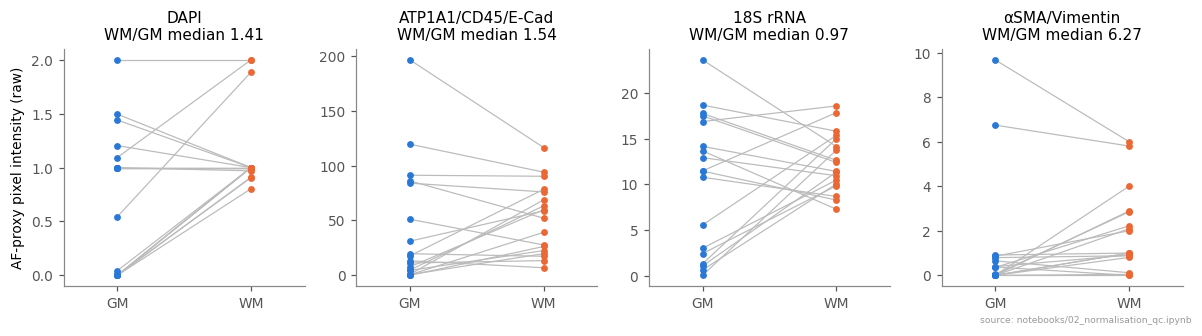

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(11, 3))
for ax, ch in zip(axs, CH):
    d = af_wg.xs(ch, level="channel")
    ax.plot([0, 1], [d.GM, d.WM], color="#bbbbbb", lw=0.8)
    ax.scatter(np.zeros(len(d)), d.GM, s=12, color=plotting.CATEGORICAL[0], zorder=3, label="GM")
    ax.scatter(np.ones(len(d)), d.WM, s=12, color=plotting.CATEGORICAL[1], zorder=3, label="WM")
    ax.set_xticks([0, 1], ["GM", "WM"]); ax.set_xlim(-0.4, 1.4)
    ax.set_title(f"{plotting.CHANNEL_LABELS[ch]}\nWM/GM median {af_sum.loc[ch, 'WM/GM']:.2f}")
axs[0].set_ylabel("AF-proxy pixel intensity (raw)")
fig.tight_layout()
plotting.save_fig(fig, "af_wm_vs_gm", OUT, SRC)

How large is background relative to cell signal? Ratio of local background to the cell's own mean
(median over cells), by region of the cell. Values near 1 mean the feature is mostly background.

In [6]:
cov = pd.concat(pd.read_parquet(p) for p in sorted(CACHE.glob("*_covariates.parquet")))
f = data.load_features(cfg)
f = f.join(cov, how="left")
f["seg"] = f.segmentation_method.map(plotting.SEG_SHORT)
f["region_class"] = np.select([f.Global_anatomical_region.isin(WM), f.Global_anatomical_region.isin(GM)],
                              ["WM", "GM"], "other")
bg_rel = pd.DataFrame({ch: (f[f"{ch}_bg_local"] / f[f"{ch}_cell_mean"]).groupby(f.region_class).median()
                       for ch in CH}).round(2)
bg_rel

,dapi,bnd,r18s,smavim
region_class,,,,
GM,0.03,1.31,0.22,1.61
WM,0.02,1.25,0.14,0.61
other,0.01,0.83,0.11,0.42


## Distance to tissue edge
Edge cells (meninges, roots, cut surfaces) get edge artefacts and different extracellular context.

cells within 20 µm of edge: 0.022 | outside tissue mask: 0.0032


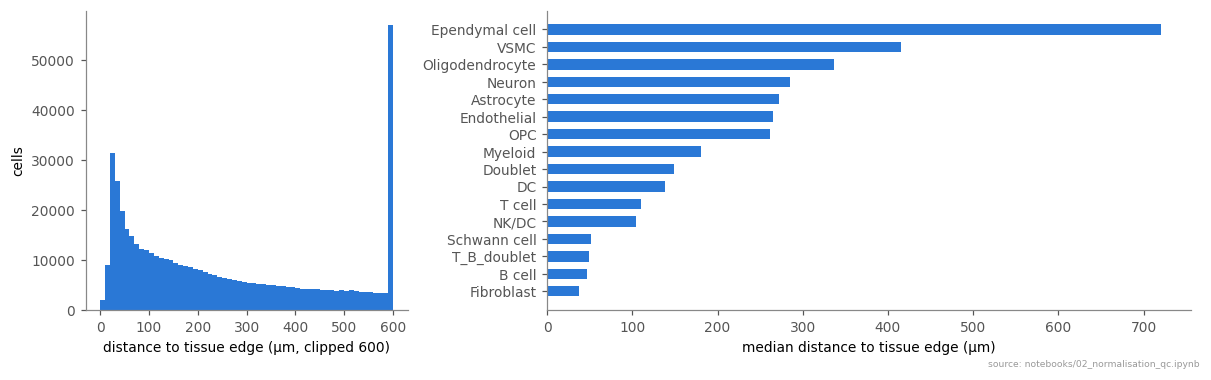

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 2]})
axs[0].hist(f.edge_um.clip(upper=600), bins=60, color=plotting.CATEGORICAL[0])
axs[0].set(xlabel="distance to tissue edge (µm, clipped 600)", ylabel="cells")
e = f.groupby("Anno_L1_curated", observed=True).edge_um.median().sort_values()
e = e[f.Anno_L1_curated.value_counts().reindex(e.index) >= 200]
axs[1].barh(e.index, e.values, color=plotting.CATEGORICAL[0], height=0.6)
axs[1].set(xlabel="median distance to tissue edge (µm)")
fig.tight_layout()
plotting.save_fig(fig, "edge_distance", OUT, SRC)
print("cells within 20 µm of edge:", (f.edge_um < 20).mean().round(3), "| outside tissue mask:", (~f.in_tissue.astype(bool)).mean().round(4))

## Normalisation

In [8]:
ref = (f.Curated_niche_state == "Physiological").values
print("reference (physiological-niche) cells per section:")
print(f[ref].groupby("section_id").size().describe().round(0).to_dict())
fn = bgm.normalise(f, CH, ref, bg="local", group="section_id")
scales = fn.groupby("section_id")[[f"{ch}_scale" for ch in CH]].first()
scales.round(1)

reference (physiological-niche) cells per section:


{'count': 18.0, 'mean': 8842.0, 'std': 2928.0, 'min': 3383.0, '25%': 7485.0, '50%': 9556.0, '75%': 10106.0, 'max': 15860.0}


/Users/christoffer/work/karolinska/development/BeyondBoundaries/src/beyondboundaries/background.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out.loc[m, f"{ch}_scale"] = s


/Users/christoffer/work/karolinska/development/BeyondBoundaries/src/beyondboundaries/background.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out.loc[m, f"{ch}_scale"] = s


/Users/christoffer/work/karolinska/development/BeyondBoundaries/src/beyondboundaries/background.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out.loc[m, f"{ch}_scale"] = s


/Users/christoffer/work/karolinska/development/BeyondBoundaries/src/beyondboundaries/background.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out.loc[m, f"{ch}_scale"] = s


,dapi_scale,bnd_scale,r18s_scale,smavim_scale
section_id,,,,
run5_C2_G1_Bot_0088858,200.699997,75.900002,702.700012,30.200001
run5_C2_G1_Mid_0088858,196.399994,100.699997,713.200012,22.100000
run5_C2_G1_Top_0088858,204.399994,156.399994,718.099976,44.500000
run5_C2_G2_Bot_0088858,182.199997,188.000000,748.200012,88.699997
run5_C2_G2_Mid_0088858,206.000000,98.300003,700.200012,21.900000
run5_C2_G2_Top_0088858,234.100006,66.699997,715.700012,29.200001
run5_C2_G3_Bot_0088870,192.500000,304.500000,647.599976,113.400002
run5_C2_G3_Mid_0088870,195.100006,228.000000,641.500000,91.000000
run5_C2_G3_Top_0088870,210.500000,184.399994,565.500000,60.799999


### Piece-level intensity vs disease
Within each section, the same reference statistic per tissue piece ÷ the section's scale (1 = like the rest of
its section). Spearman ρ with clinical score at sacrifice and with the piece's lesion-niche fraction. A positive
ρ for a channel means that stain is brighter, in *physiological-niche* cells, in sicker animals — biology that a
per-piece normalisation would remove.

In [9]:
from scipy.stats import spearmanr

pc = {}
for ch in CH:
    p90 = f[ref].groupby("meta_sample_id", observed=True)[f"{ch}_cell_mean"].quantile(0.9)
    pc[f"{ch}_rel"] = p90 / fn[ref].groupby("meta_sample_id", observed=True)[f"{ch}_scale"].first()
piece = pd.DataFrame(pc).join(f.groupby("meta_sample_id", observed=True).agg(
    score=("score_sacrifice", "first"), n=("section_id", "size"),
    lesion_frac=("Curated_niche_state", lambda s: s.astype(str).str.startswith("Lesion").mean())))
piece = piece[piece.n >= 1000]
rows = []
for ch in CH:
    for cov_ in ("score", "lesion_frac"):
        r, pval = spearmanr(piece[f"{ch}_rel"], piece[cov_], nan_policy="omit")
        rows.append(dict(channel=ch, covariate=cov_, rho=round(r, 2), p=float(f"{pval:.2g}")))
piece_tests = pd.DataFrame(rows).pivot(index="channel", columns="covariate", values=["rho", "p"])
piece_tests.to_csv(OUT / "piece_intensity_vs_disease.csv")
print(len(piece), "pieces with >= 1000 cells")
piece_tests

51 pieces with >= 1000 cells


rho                 p        
covariate lesion_frac score lesion_frac   score
channel                                        
bnd             -0.20 -0.22     0.15000  0.1200
dapi             0.27  0.35     0.05200  0.0120
r18s            -0.42 -0.29     0.00230  0.0370
smavim           0.45  0.43     0.00084  0.0016

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/02_normalisation_qc/piece_intensity_vs_lesion.png')

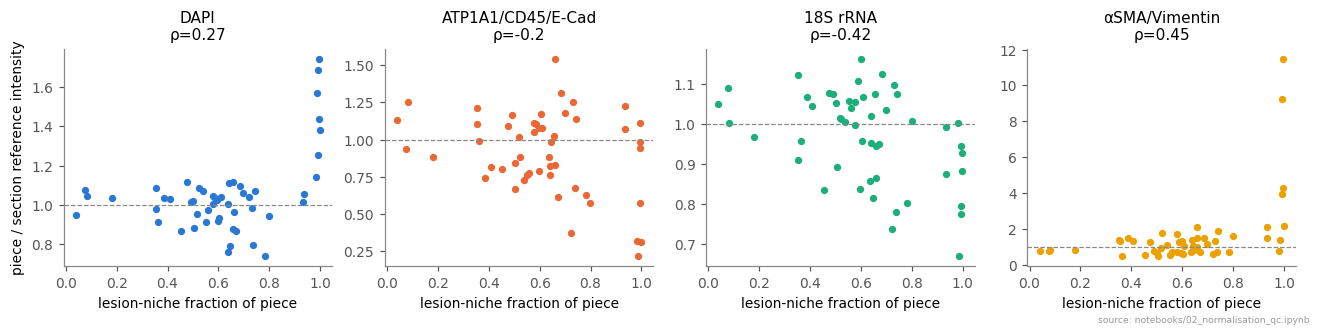

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3), sharey=False)
for ax, ch in zip(axs, CH):
    ax.scatter(piece.lesion_frac, piece[f"{ch}_rel"], s=14, color=plotting.CHANNEL_COLORS[ch])
    ax.axhline(1, color="#888888", lw=0.8, ls="--")
    ax.set(xlabel="lesion-niche fraction of piece", title=f"{plotting.CHANNEL_LABELS[ch]}\n"
           f"ρ={piece_tests.loc[ch, ('rho', 'lesion_frac')]}")
axs[0].set_ylabel("piece / section reference intensity")
fig.tight_layout()
plotting.save_fig(fig, "piece_intensity_vs_lesion", OUT, SRC)

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/02_normalisation_qc/normalisation_oligos.png')

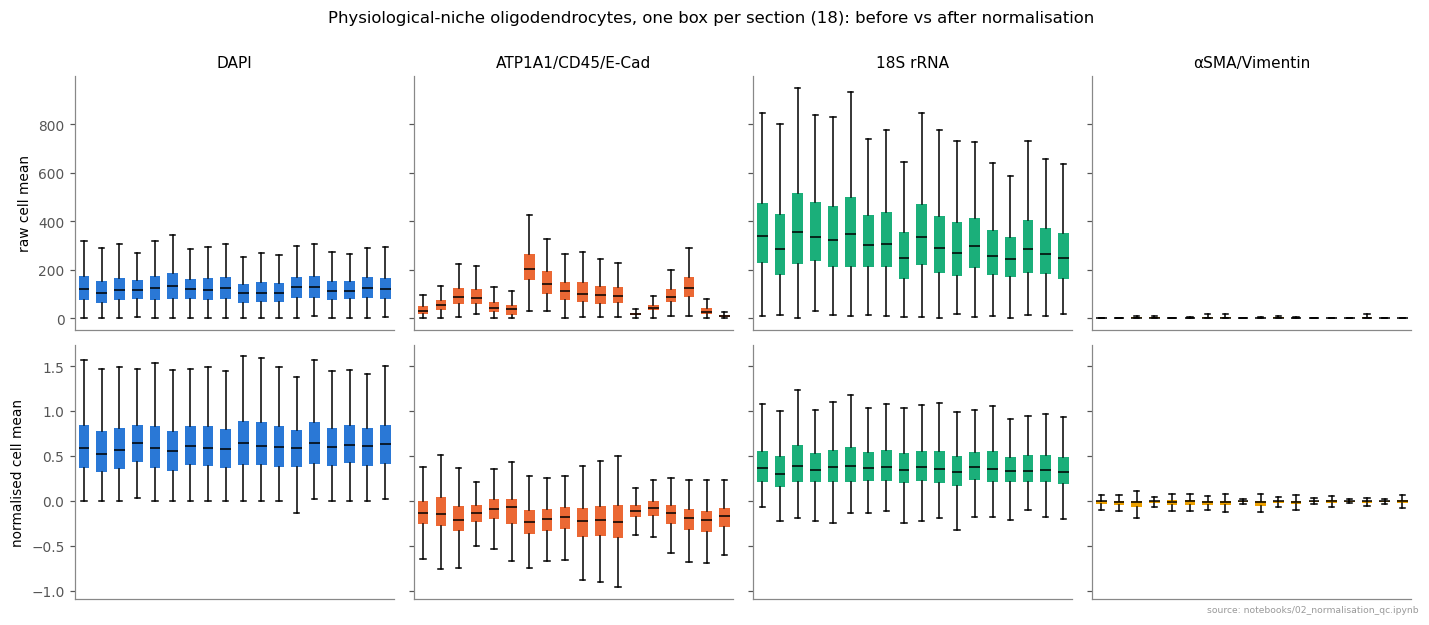

In [11]:
oli = (f.Anno_L1_curated == "Oligodendrocyte") & ref
secs = sorted(f.section_id.unique())
fig, axs = plt.subplots(2, 4, figsize=(13, 5.5), sharey="row")
for j, ch in enumerate(CH):
    for i, (frame, lab) in enumerate([(f, "raw cell mean"), (fn, "normalised cell mean")]):
        vals = [frame.loc[oli & (f.section_id == s), f"{ch}_cell_mean"] for s in secs]
        bp = axs[i, j].boxplot(vals, showfliers=False, patch_artist=True, widths=0.6,
                               medianprops=dict(color="black", lw=1))
        for bx in bp["boxes"]:
            bx.set(facecolor=plotting.CHANNEL_COLORS[ch], edgecolor="none")
        axs[i, j].set_xticks([])
        if j == 0:
            axs[i, j].set_ylabel(lab)
    axs[0, j].set_title(plotting.CHANNEL_LABELS[ch])
fig.suptitle("Physiological-niche oligodendrocytes, one box per section (18): before vs after normalisation", y=1.0)
fig.tight_layout()
plotting.save_fig(fig, "normalisation_oligos", OUT, SRC)

In [12]:
# between-section CV of the median normalised cell mean, judged on physiological-niche cells that carry the stain
# (DAPI/18S only: for ATP1A1 and αSMA/Vim most cells sit at background after subtraction, so a CV is meaningless)
POS = {"dapi": ["Oligodendrocyte"], "r18s": ["Neuron"]}
rows = {}
for ch, types in POS.items():
    m = ref & f.Anno_L1_curated.isin(types).values
    for lab, frame in (("raw", f), ("normalised", fn)):
        med = frame.loc[m, f"{ch}_cell_mean"].groupby(f.section_id[m]).median()
        rows.setdefault(f"{ch} ({types[0]})", {})[lab] = round(med.std() / abs(med.mean()), 3)
pd.DataFrame(rows).T

,raw,normalised
dapi (Oligodendrocyte),0.077,0.052
r18s (Neuron),0.099,0.065


## QC after normalisation: by segmentation method
Interior (18S)-segmented cells dominate; boundary and nucleus-expansion cells are few but must be checked
separately because the stains defined the masks.

seg,boundary,interior (18S),nucleus exp.
Anno_L1_curated,,,
Astrocyte,0.011,0.959,0.031
B cell,0.007,0.981,0.012
DC,0.010,0.967,0.024
Doublet,0.050,0.759,0.191
Endothelial,0.014,0.962,0.024
Ependymal cell,0.049,0.941,0.010
Epithelial,0.056,0.722,0.222
Fibroblast,0.020,0.962,0.018
Muscle cell,0.000,0.952,0.048


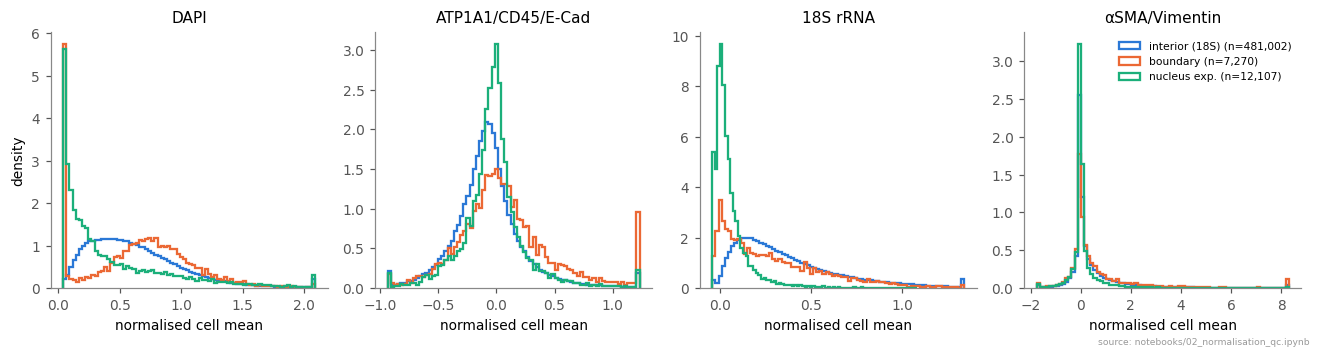

In [13]:
segs = ["interior (18S)", "boundary", "nucleus exp."]
fig, axs = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, ch in zip(axs, CH):
    for k, s in enumerate(segs):
        v = fn.loc[fn.seg == s, f"{ch}_cell_mean"].dropna()
        lo, hi = np.nanpercentile(fn[f"{ch}_cell_mean"], [0.5, 99.5])
        ax.hist(v.clip(lo, hi), bins=80, density=True, histtype="step", lw=1.5, color=plotting.CATEGORICAL[k],
                label=f"{s} (n={len(v):,})")
    ax.set_title(plotting.CHANNEL_LABELS[ch]); ax.set_xlabel("normalised cell mean")
axs[0].set_ylabel("density"); axs[-1].legend(fontsize=7, loc="upper right")
fig.tight_layout()
plotting.save_fig(fig, "normalised_by_segmethod", OUT, SRC)
pd.crosstab(fn.Anno_L1_curated, fn.seg, normalize="index").round(3)

## Spatial heatmaps of each channel (level 5, 6.8 µm/px)
Same contrast per channel across sections (1st–99.5th percentile of tissue pixels pooled over sections).

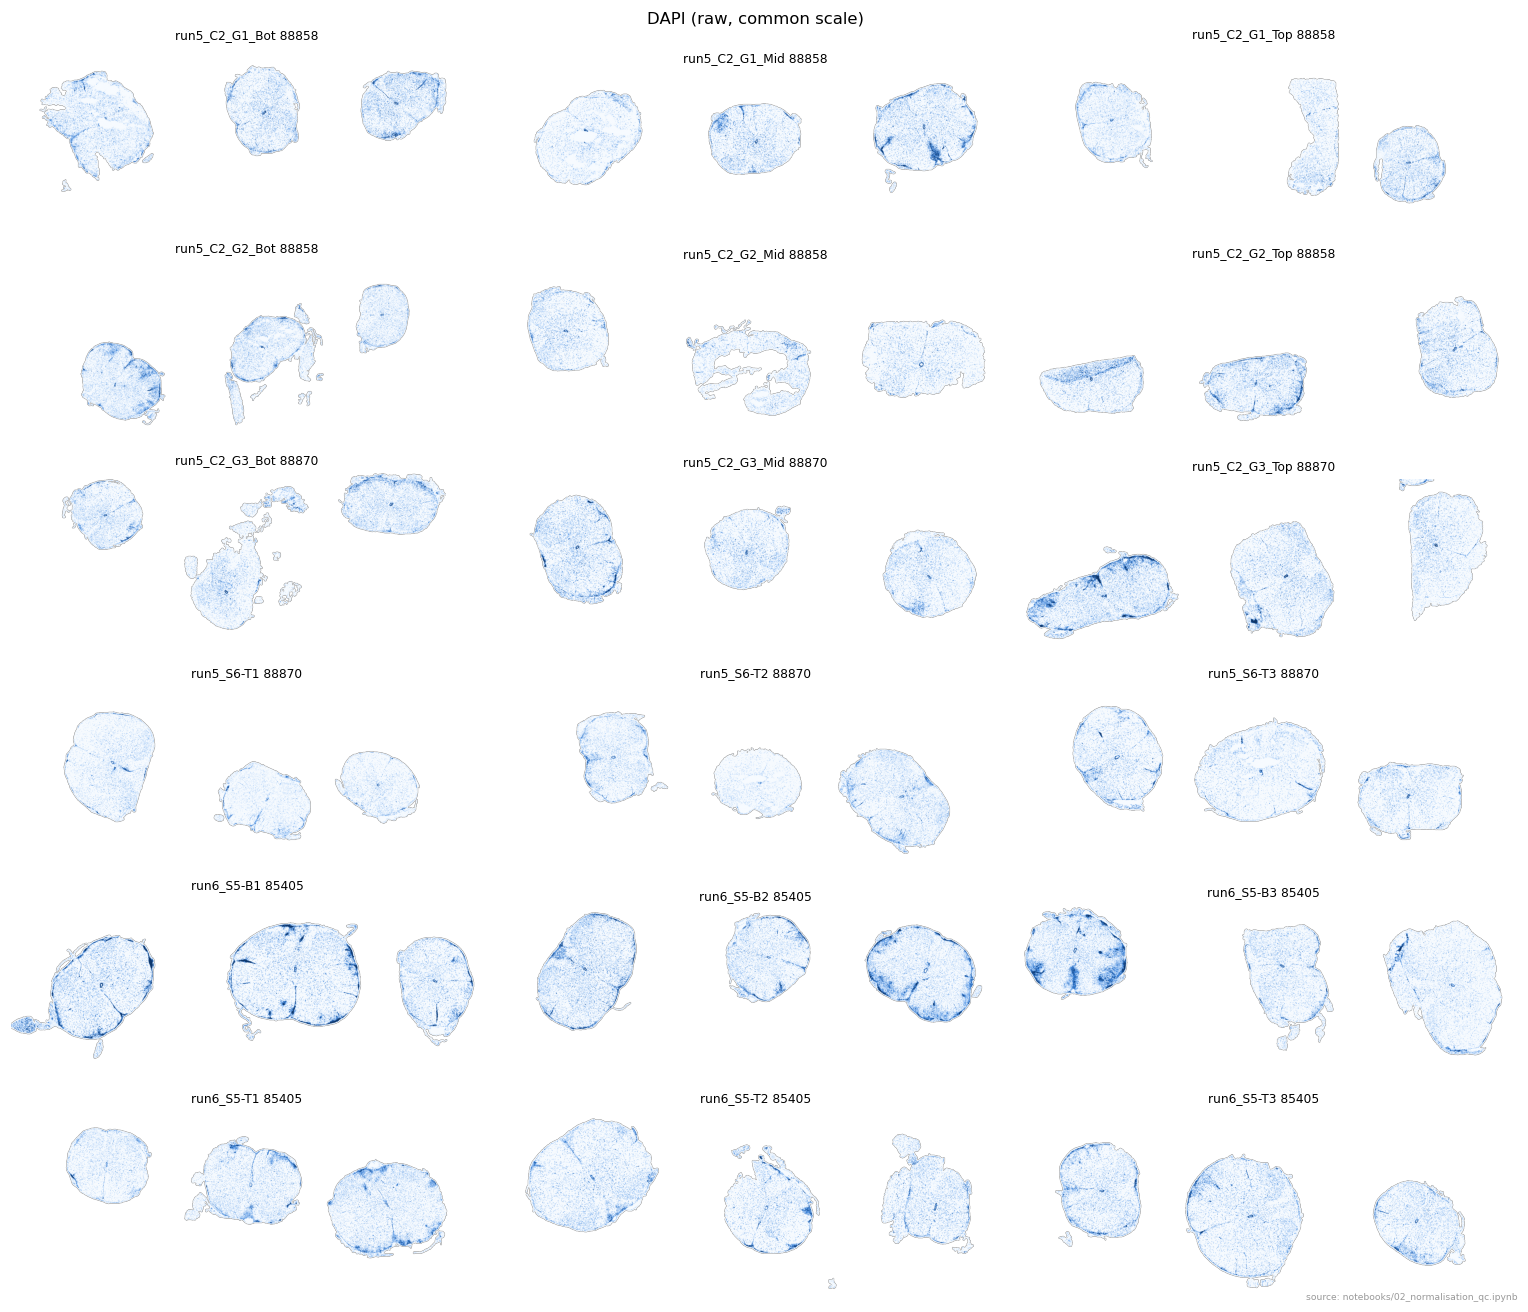

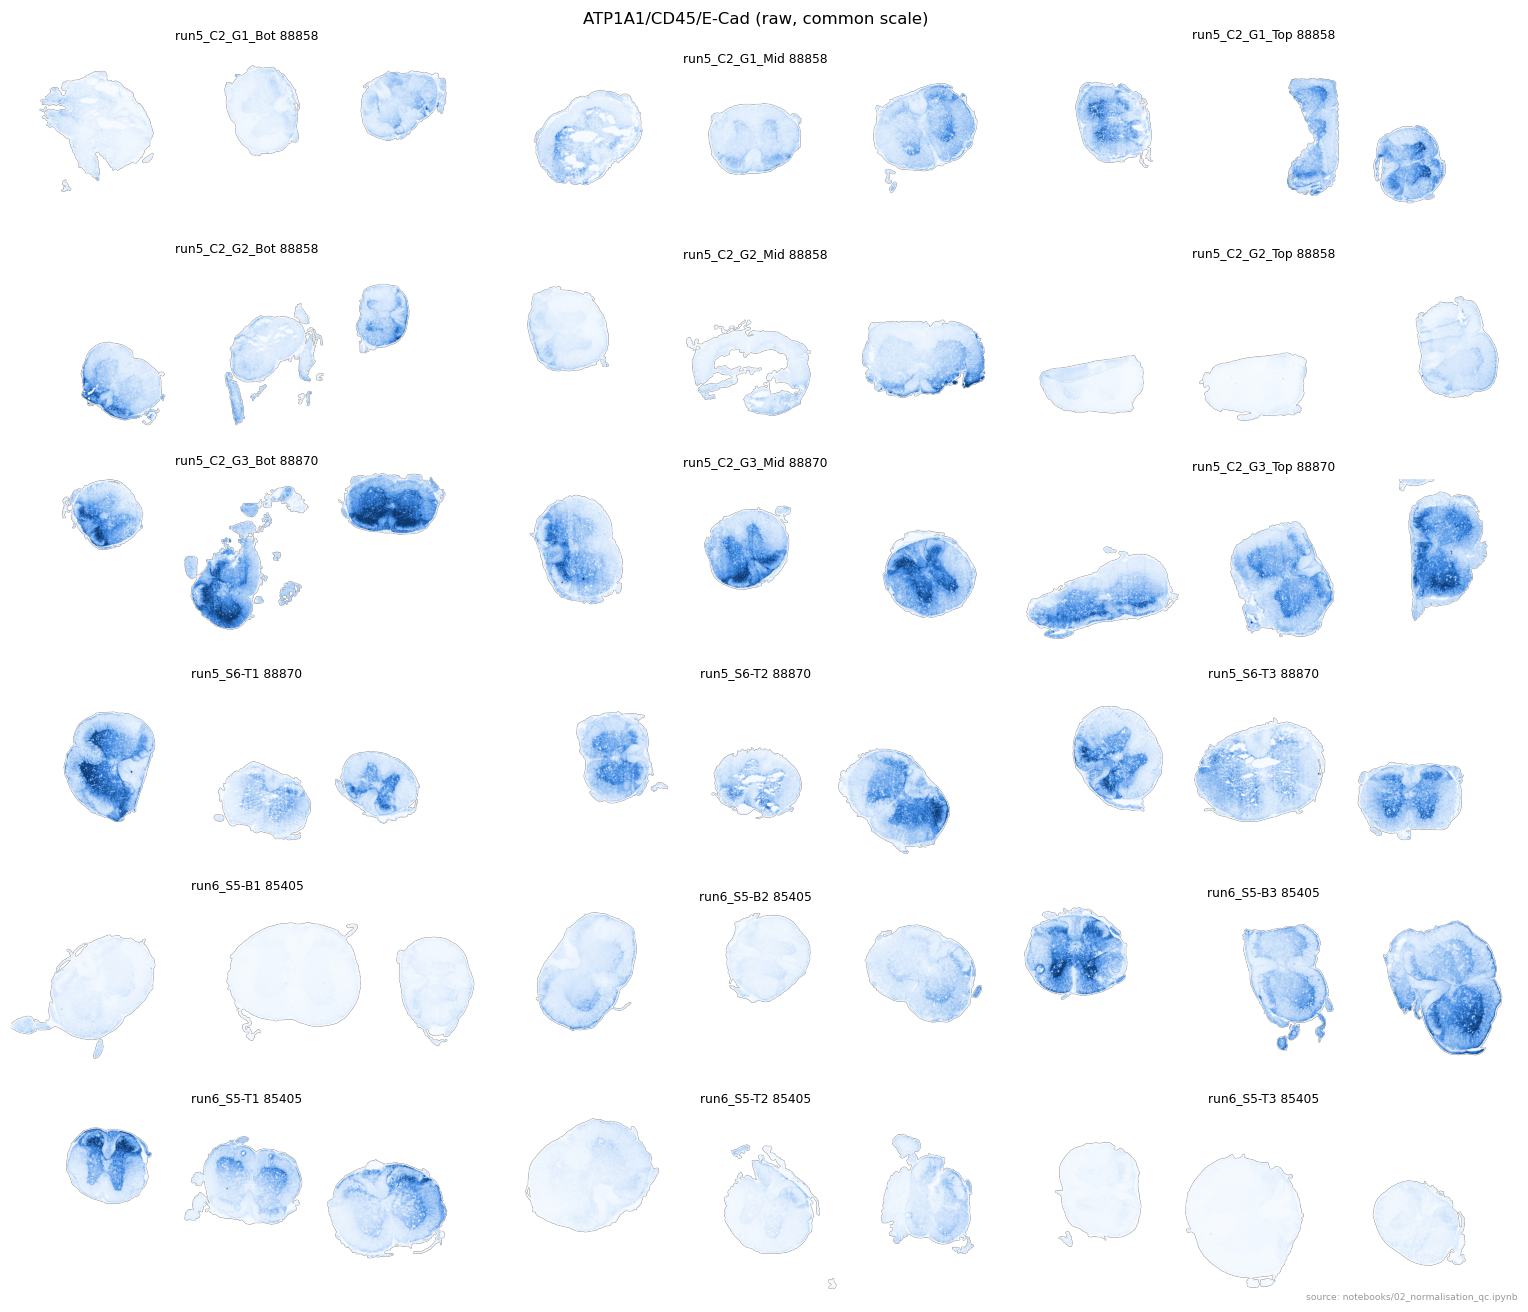

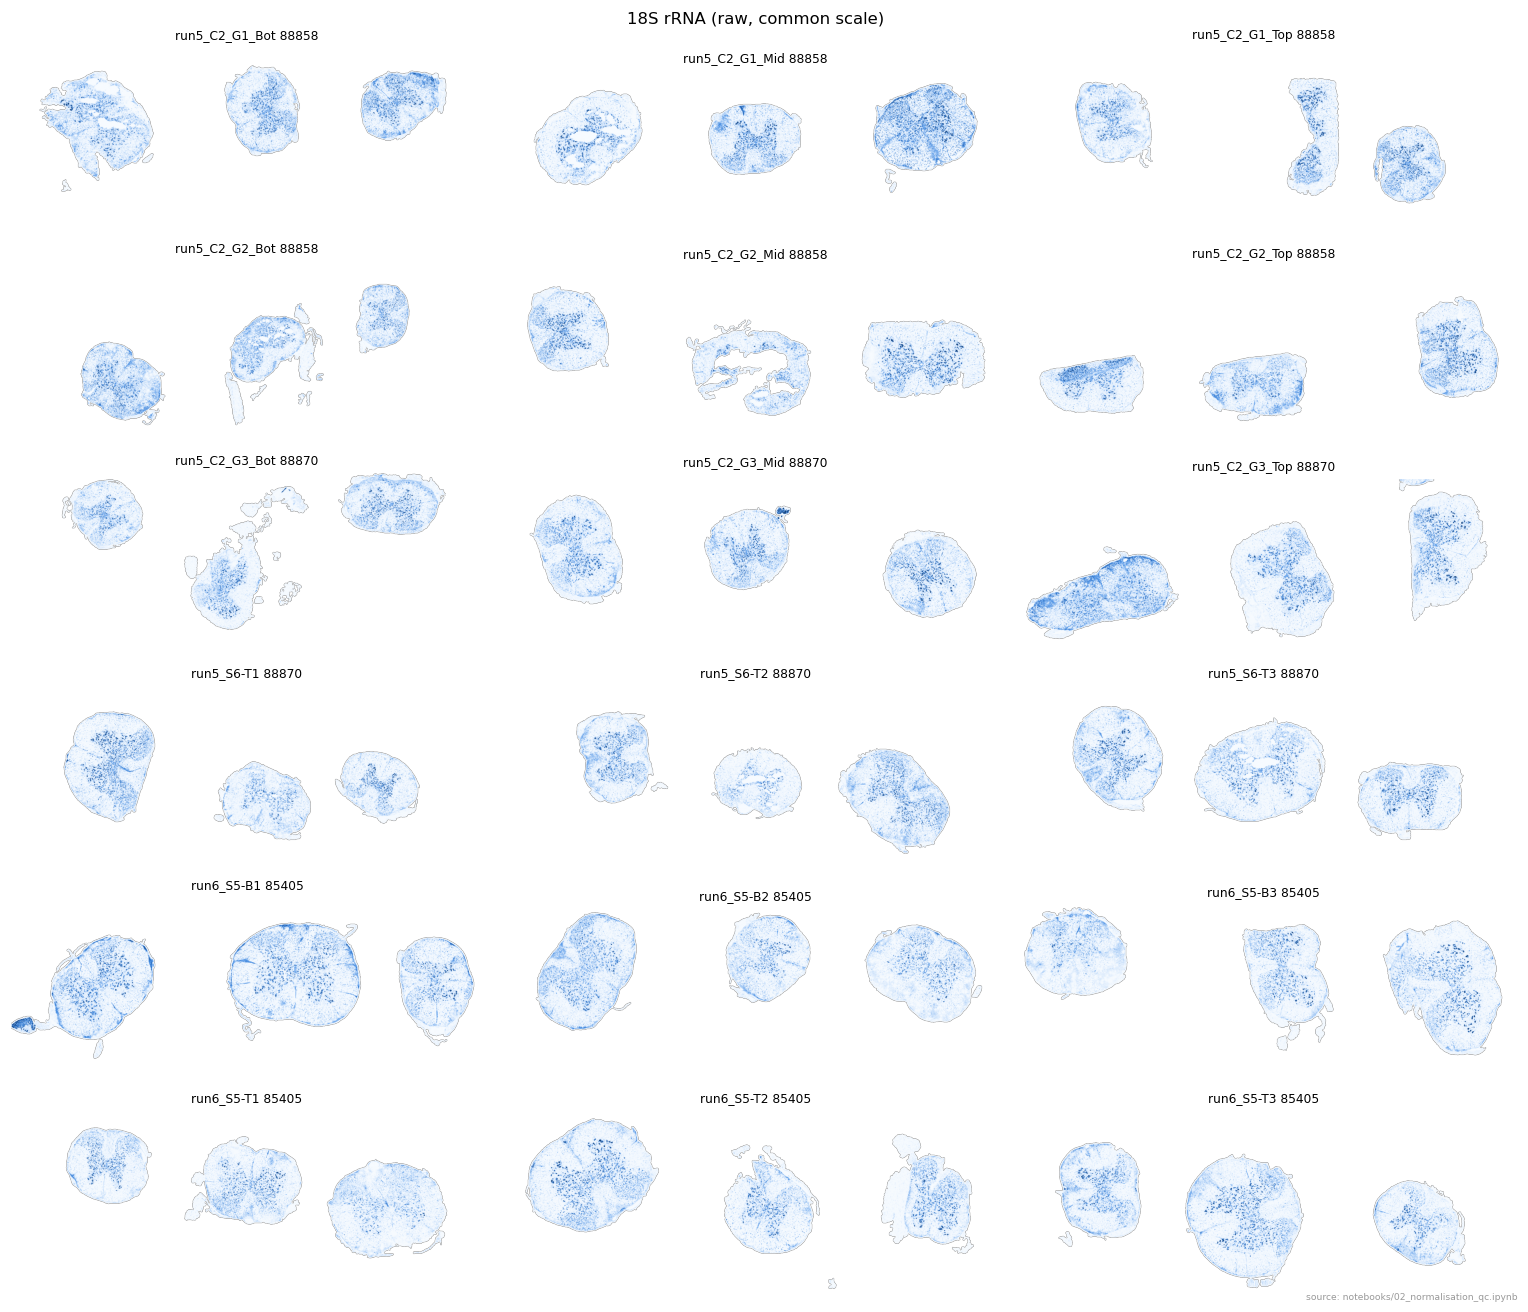

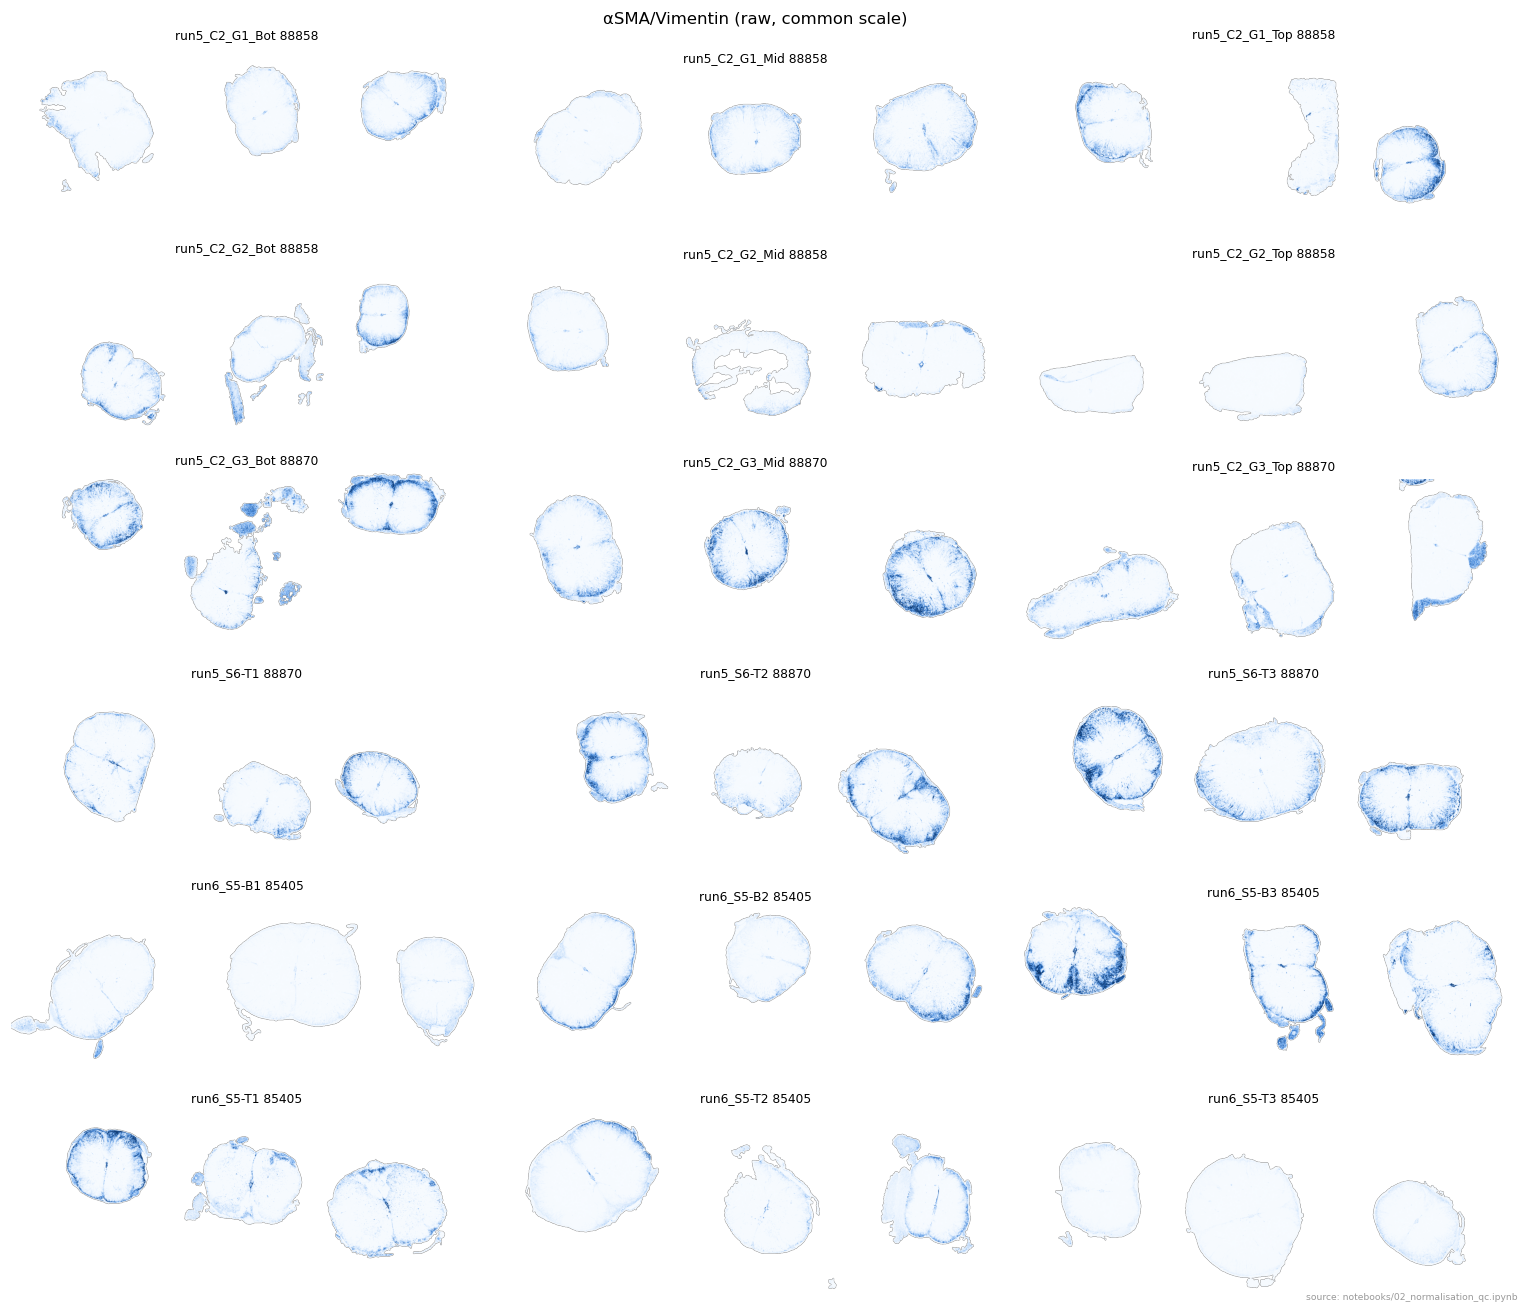

In [14]:
th = {s: np.load(CACHE / f"{s}_thumbs.npz") for s in secs}
for ch in CH:
    pool = np.concatenate([th[s][ch][th[s]["tissue"]] for s in secs])
    lo, hi = np.percentile(pool, [1, 99.5])
    fig, axs = plt.subplots(6, 3, figsize=(14, 12))
    for ax, s in zip(axs.ravel(), secs):
        im = np.where(th[s]["tissue"], th[s][ch], np.nan)
        ax.imshow(im, cmap=plotting.SEQ, vmin=lo, vmax=hi)
        ax.set_title(s.replace("_00", " "), fontsize=8); ax.axis("off")
    fig.suptitle(f"{plotting.CHANNEL_LABELS[ch]} (raw, common scale)")
    fig.tight_layout()
    plotting.save_fig(fig, f"spatial_{ch}", OUT, SRC)
    plt.show()

## Save the normalised table
`data/features_norm.parquet`: annotated cells, normalised intensities + all other features + covariates
(edge distance, local/global background, scales) + annotation columns.

In [15]:
fn.drop(columns=["in_tissue"]).to_parquet(ROOT / "data" / "features_norm.parquet")
print(fn.shape)

(500379, 233)
